# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Lioneil Diyoel Trystan Tikupadang | 5054251037|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

df = pd.read_csv('diabetes.csv')

print("Informasi Dasar Dataset:")
df.info()

print("\nJumlah Baris dan Kolom:", df.shape)

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Value Aktual (Null):")
print(df.isnull().sum())

Informasi Dasar Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Jumlah Baris dan Kolom: (768, 9)

Statistik Deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Jumlah Missing Value Aktual (Null):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\Lio\AppData\Local\Temp\ipykernel_2448\1940295249.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


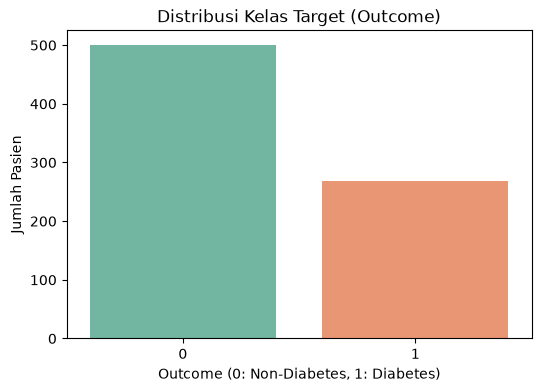

Persentase Distribusi Kelas (Imbalance Check):
 Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Outcome)')
plt.xlabel('Outcome (0: Non-Diabetes, 1: Diabetes)')
plt.ylabel('Jumlah Pasien')
plt.show()

print("Persentase Distribusi Kelas (Imbalance Check):\n", df['Outcome'].value_counts(normalize=True) * 100)

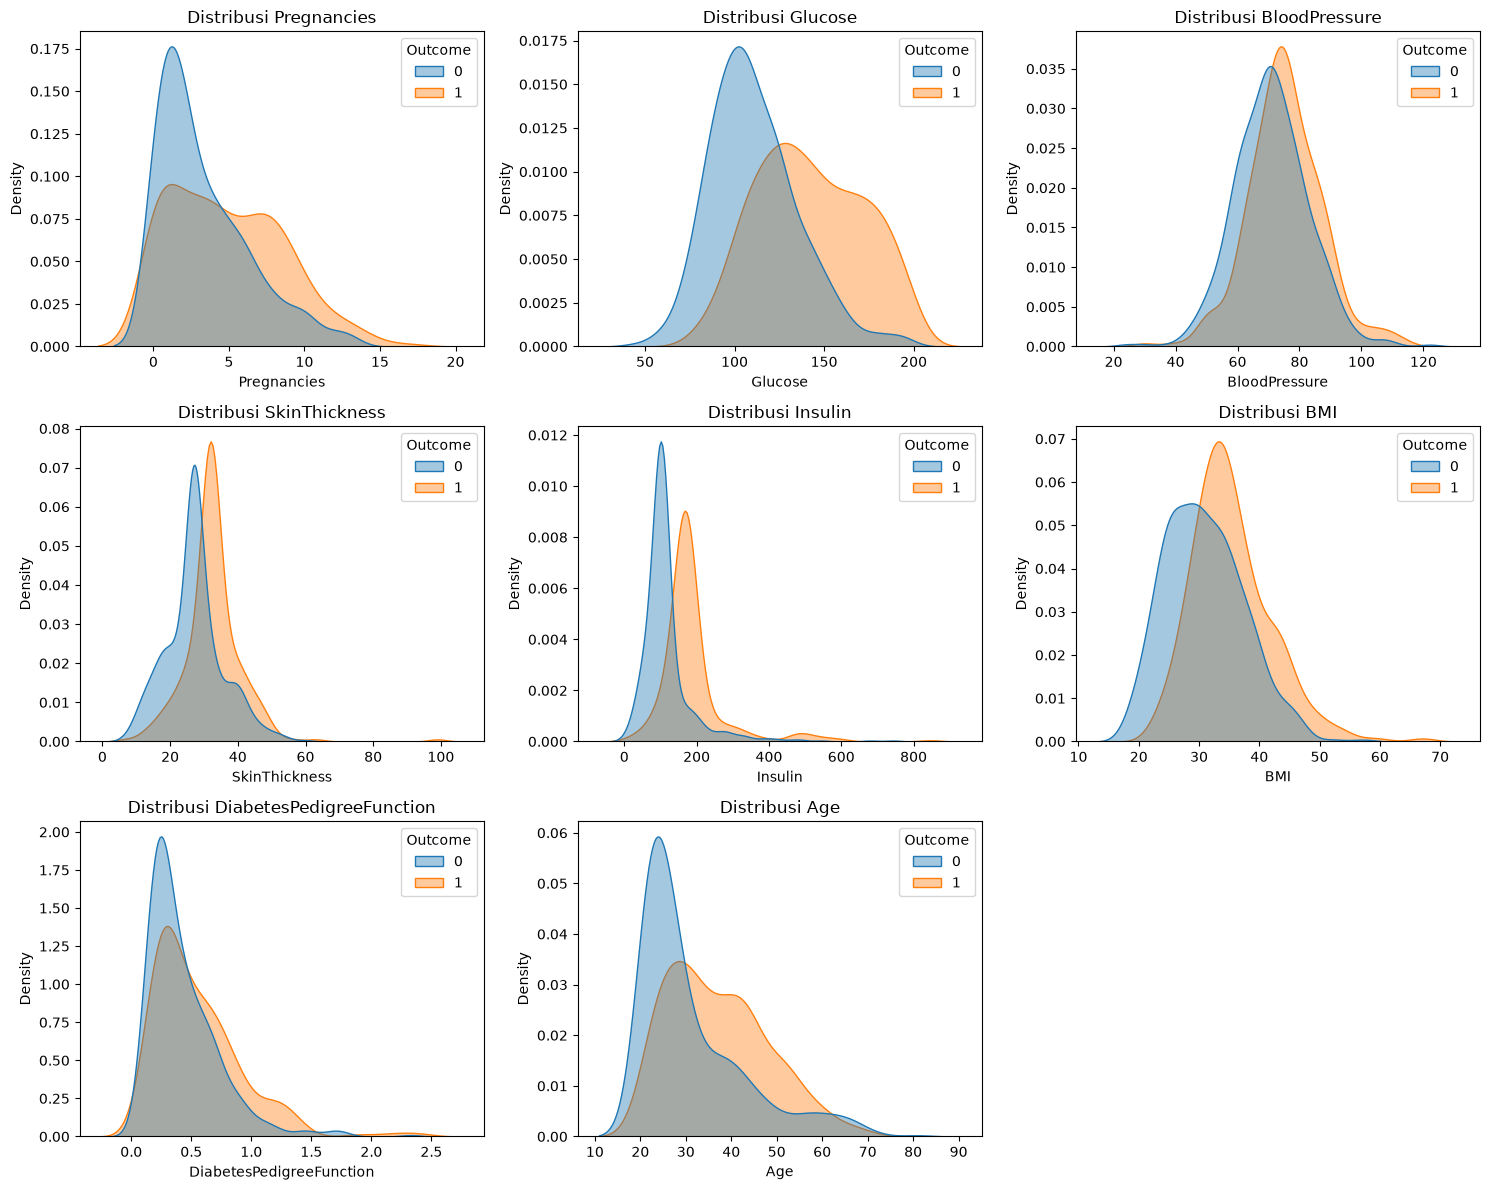

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.

features = df.columns[:-1]
plt.figure(figsize=(15, 12))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=df, x=feature, hue="Outcome", fill=True, common_norm=False, alpha=0.4)
    plt.title(f'Distribusi {feature}')
plt.tight_layout()
plt.show()

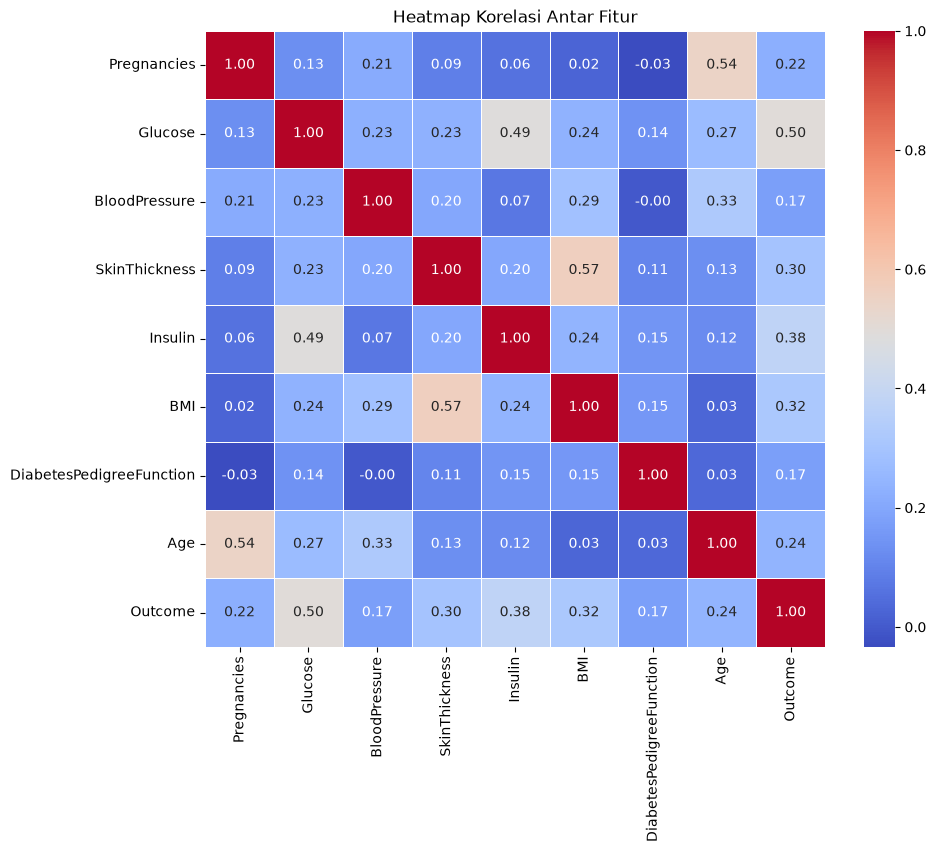

In [5]:
# Tampilkan heatmap korelasi antar fitur.

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

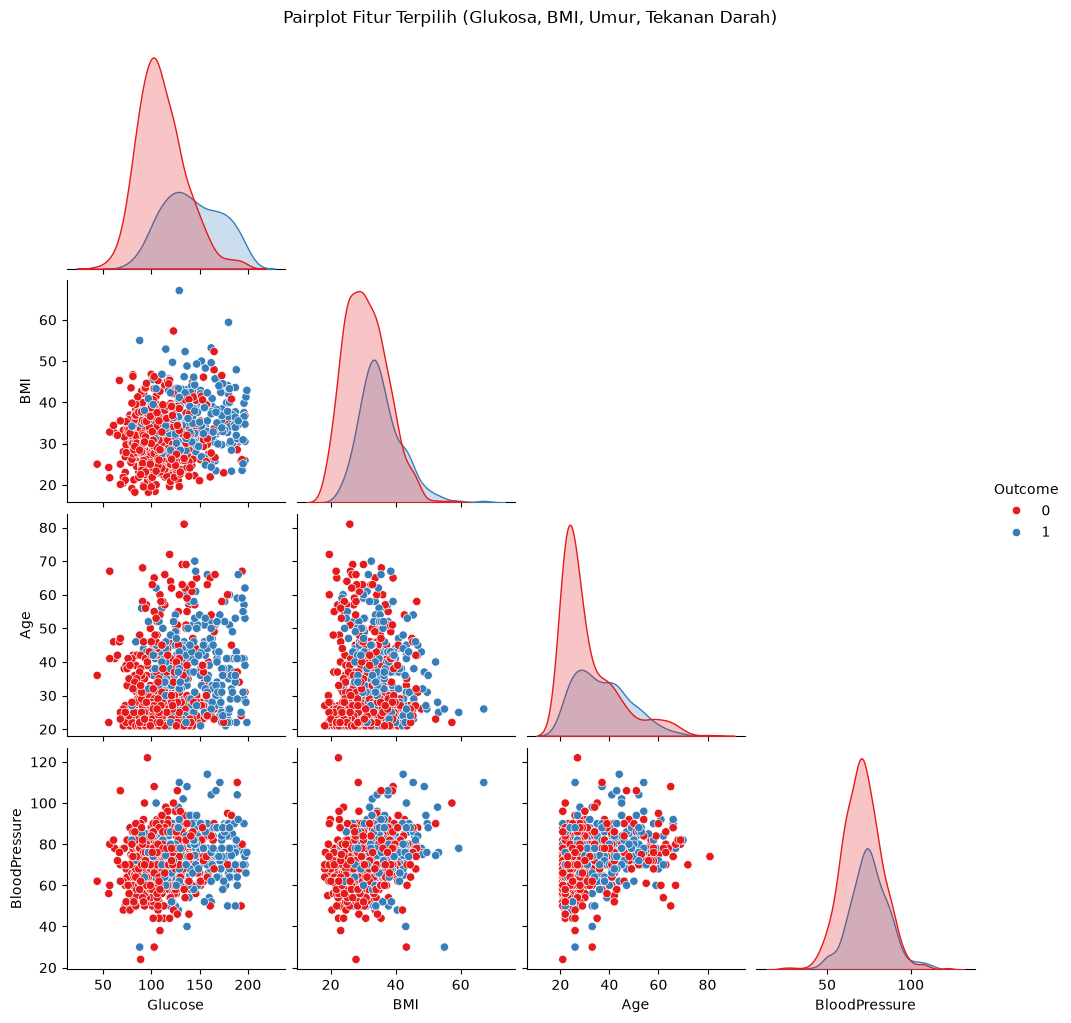

In [6]:
# EDA Tambahan: Pairplot untuk melihat hubungan antar beberapa fitur terpenting dengan Outcome

sns.pairplot(df[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Outcome']], hue='Outcome', palette='Set1', corner=True)
plt.suptitle('Pairplot Fitur Terpilih (Glukosa, BMI, Umur, Tekanan Darah)', y=1.02)
plt.show()

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah indikasi missing value berbentuk angka 0:")
for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count}")



Jumlah indikasi missing value berbentuk angka 0:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [9]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

print("\nSemua nilai 0 tidak valid telah diubah menjadi NaN sementara untuk menunggu proses split.")


Semua nilai 0 tidak valid telah diubah menjadi NaN sementara untuk menunggu proses split.


In [10]:
# Pisahkan fitur (X) dan target (y).

X = df.drop('Outcome', axis=1)
y = df['Outcome']
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pengisian Missing Value untuk mencegah Leakage
for col in cols_with_zero:
    median_val = X_train[col].median()
    X_train.loc[:, col] = X_train[col].fillna(median_val)
    X_test.loc[:, col] = X_test[col].fillna(median_val)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (614, 8)
Ukuran X_test: (154, 8)


In [11]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

scaler = StandardScaler()

# Fit dan transform pada X_train
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Transform (Tanpa Fit) pada X_test
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

display(X_train_scaled.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
1,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
2,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
3,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
4,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [12]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]
print("Prediksi menggunakan Gaussian Naive Bayes selesai.")

Prediksi menggunakan Gaussian Naive Bayes selesai.


## 3.2 Logistic Regression

In [14]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
print("Prediksi menggunakan Logistic Regression selesai.")

Prediksi menggunakan Logistic Regression selesai.


# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

def evaluasi_model(y_true, y_pred, nama_model):
    print(f"--- Metrik Evaluasi {nama_model} ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}\n")

evaluasi_model(y_test, y_pred_gnb, "Gaussian Naive Bayes")
evaluasi_model(y_test, y_pred_logreg, "Logistic Regression")

--- Metrik Evaluasi Gaussian Naive Bayes ---
Accuracy  : 0.7273
Precision : 0.6034
Recall    : 0.6481
F1-Score  : 0.6250

--- Metrik Evaluasi Logistic Regression ---
Accuracy  : 0.7078
Precision : 0.5882
Recall    : 0.5556
F1-Score  : 0.5714



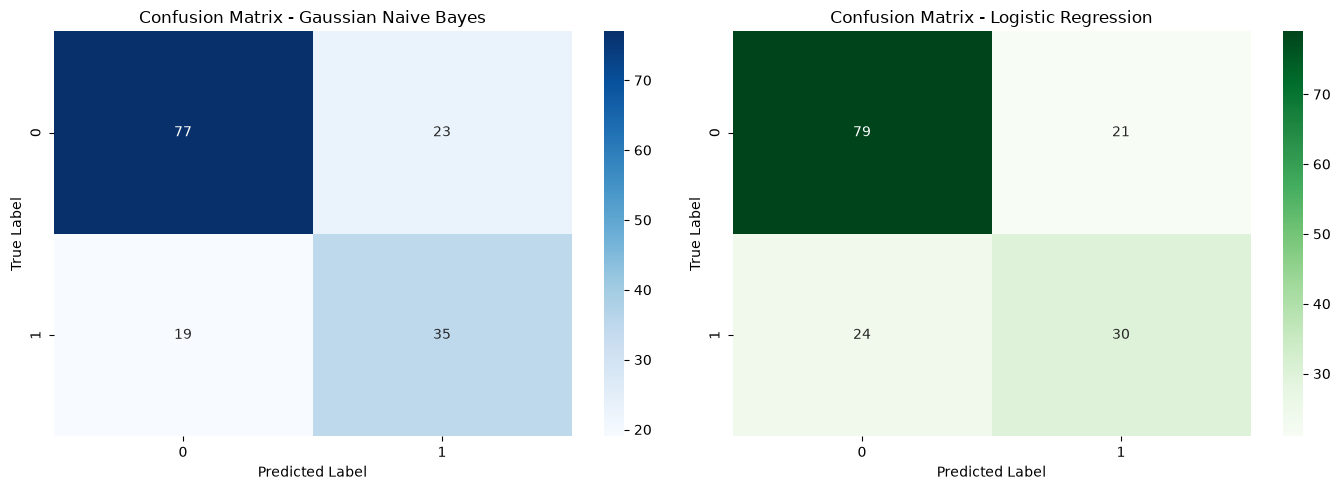

In [17]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriks Konfusi GNB
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Gaussian Naive Bayes')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Matriks Konfusi LogReg
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

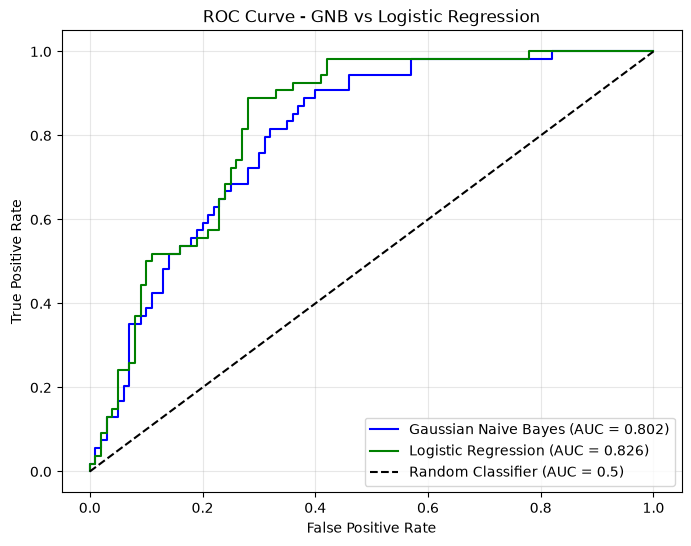

In [18]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
auc_gnb = auc(fpr_gnb, tpr_gnb)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian Naive Bayes (AUC = {auc_gnb:.3f})', color='blue')
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.title('ROC Curve - GNB vs Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

C:\Users\Lio\AppData\Local\Temp\ipykernel_2448\1448332866.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Koefisien', y='Fitur', data=coef_df, palette='vlag')


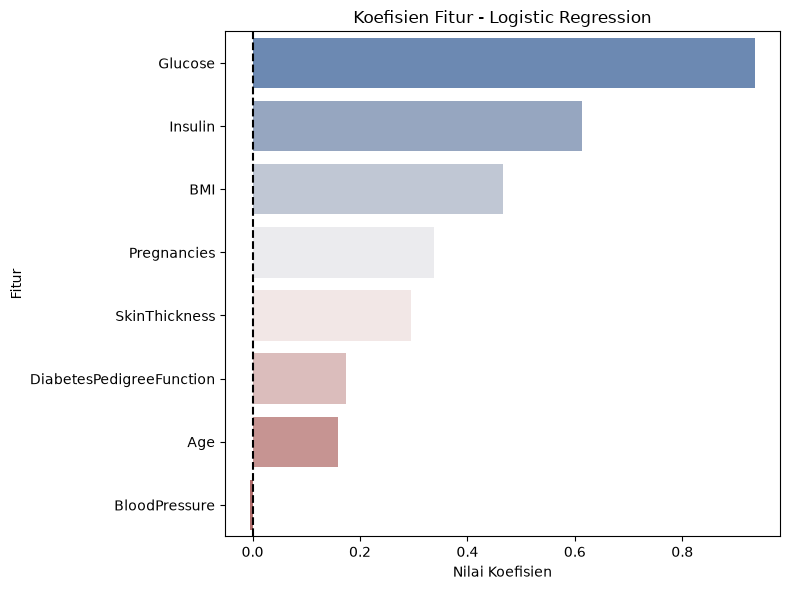

In [19]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

coef_df = pd.DataFrame({'Fitur': X_train.columns, 'Koefisien': logreg.coef_[0]})
coef_df = coef_df.sort_values(by='Koefisien', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Koefisien', y='Fitur', data=coef_df, palette='vlag')
plt.title('Koefisien Fitur - Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksperimen, Gaussian Naive Bayes dan Logistic Regression dapat digunakan untuk memprediksi apakah seseorang mengalami diabetes atau tidak. Setelah data dibagi menjadi data training dan testing serta dilakukan standardisasi, kedua model kemudian dievaluasi menggunakan accuracy, precision, recall, F1-score, confusion matrix, dan ROC-AUC.

Gaussian Naive Bayes memperoleh accuracy **72,73%**, precision **60,34%**, recall **64,81%**, dan F1-score **62,50%**. Sementara itu, Logistic Regression memperoleh accuracy **70,78%**, precision **58,82%**, recall **55,56%**, dan F1-score **57,14%**. Berdasarkan hasil tersebut, Gaussian Naive Bayes memiliki nilai accuracy, precision, recall, dan F1-score yang lebih tinggi dibandingkan Logistic Regression.

Pada confusion matrix, Gaussian Naive Bayes juga lebih sedikit salah memprediksi pasien diabetes sebagai non-diabetes, yaitu **19 data**, sedangkan Logistic Regression sebanyak **24 data**. Namun, dari ROC-AUC, Logistic Regression mendapatkan nilai **0,826**, sedikit lebih tinggi dibandingkan Gaussian Naive Bayes yaitu **0,802**. Hal ini menunjukkan bahwa performa kedua model dapat terlihat berbeda tergantung metrik evaluasi yang digunakan.

Perbedaan hasil juga berkaitan dengan cara kerja masing-masing model. Gaussian Naive Bayes mengasumsikan fitur mengikuti distribusi tertentu dan saling independen, sedangkan Logistic Regression memodelkan hubungan antara fitur dan probabilitas kelas. Dari hasil Logistic Regression, fitur **Glucose** memiliki koefisien paling besar dan positif, sehingga fitur ini cukup berpengaruh terhadap prediksi diabetes. Hal ini juga sesuai dengan hasil analisis korelasi pada dataset.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Berdasarkan eksperimen yang telah dilakukan, Gaussian Naive Bayes dan Logistic Regression sama-sama dapat digunakan untuk melakukan klasifikasi diabetes pada dataset yang digunakan.

Gaussian Naive Bayes menghasilkan accuracy **72,73%**, precision **60,34%**, recall **64,81%**, dan F1-score **62,50%**. Logistic Regression menghasilkan accuracy **70,78%**, precision **58,82%**, recall **55,56%**, dan F1-score **57,14%**. Berdasarkan metrik tersebut, Gaussian Naive Bayes menghasilkan hasil yang lebih tinggi pada data testing.

Namun, berdasarkan ROC-AUC, Logistic Regression memperoleh nilai **0,826**, sedangkan Gaussian Naive Bayes memperoleh nilai sekitar **0,802**. Hal ini menunjukkan bahwa Logistic Regression tetap memiliki kemampuan yang baik dalam membedakan kedua kelas ketika berbagai threshold dipertimbangkan.

Hasil eksperimen juga menunjukkan bahwa `Glucose` menjadi salah satu fitur yang paling berpengaruh terhadap prediksi diabetes pada Logistic Regression, yang sejalan dengan hasil analisis korelasi pada tahap EDA.

Untuk eksperimen selanjutnya, performa model dapat dicoba ditingkatkan dengan melakukan tuning parameter dan mencoba beberapa metode preprocessing lain. Selain itu, dapat dilakukan pengujian menggunakan model lain sebagai perbandingan.

Karena dataset memiliki distribusi kelas yang tidak sepenuhnya seimbang, evaluasi sebaiknya tidak hanya menggunakan accuracy. Recall, precision, F1-score, confusion matrix, dan ROC-AUC juga perlu diperhatikan agar kemampuan model dalam mendeteksi pasien yang benar-benar mengalami diabetes dapat dilihat dengan lebih jelas.

Untuk pengembangan lebih lanjut, threshold Logistic Regression juga dapat diubah untuk melihat apakah jumlah pasien diabetes yang salah diklasifikasikan sebagai non-diabetes dapat dikurangi.
